<a href="https://colab.research.google.com/github/NataliaArenasP20/LaboratorioBiosenales/blob/main/PARCIAL/ParcialNataliaArenas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

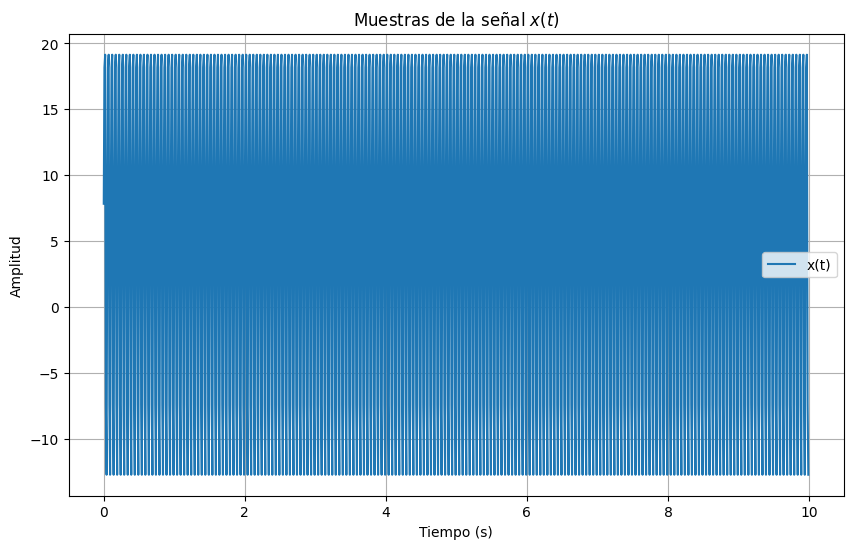

Primeras 10 muestras de la señal:
[  7.82842712  18.16826393  19.14416064  -7.39609654 -12.74475515
   7.82842712  18.16826393  19.14416064  -7.39609654 -12.74475515]


In [1]:
#PUNTO 4
import numpy as np
import matplotlib.pyplot as plt

a = 8
k = 2 * (a + 1)
fs = 100
T = 10
Ts = 1 / fs
t = np.arange(0, T, Ts)  # Vector de tiempo
x = 4 * np.cos(80 * np.pi * t + np.pi / 4) + k * np.sin(40 * np.pi * t) + 5

plt.figure(figsize=(10, 6))
plt.plot(t, x, label='x(t)')
plt.title("Muestras de la señal $x(t)$")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid()
plt.legend()
plt.show()

print("Primeras 10 muestras de la señal:")
print(x[:10])


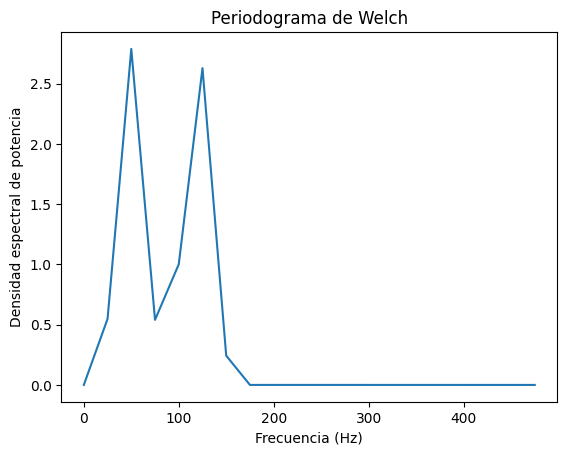

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def welch_periodogram(x, M, S):
    N = len(x)
    num_segments = int(np.floor((N - M) / S) + 1)
    w = np.hamming(M)

    Pxx = np.zeros(M)

    for i in range(num_segments):
        start = i * S
        end = start + M
        segment = x[start:end]

        segment_windowed = segment * w

        fft_segment = np.fft.fft(segment_windowed)

        periodogram = np.abs(fft_segment) ** 2 / M
        a
        Pxx += periodogram

    Pxx /= num_segments

    return Pxx

if __name__ == "__main__":
    fs = 1000  # Frecuencia de muestreo
    T = 1  # Duración en segundos
    t = np.arange(0, T, 1/fs)
    x = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 120 * t)  # Señal con dos componentes de frecuencia

    M = 40  # Longitud de cada segmento
    S = 30  # Solapamiento
    Pxx = welch_periodogram(x, M, S)

    f = np.fft.fftfreq(M, 1/fs)

    plt.plot(f[:M//2], Pxx[:M//2]
    plt.xlabel('Frecuencia (Hz)')
    plt.ylabel('Densidad espectral de potencia')
    plt.title('Periodograma de Welch')
    plt.show()


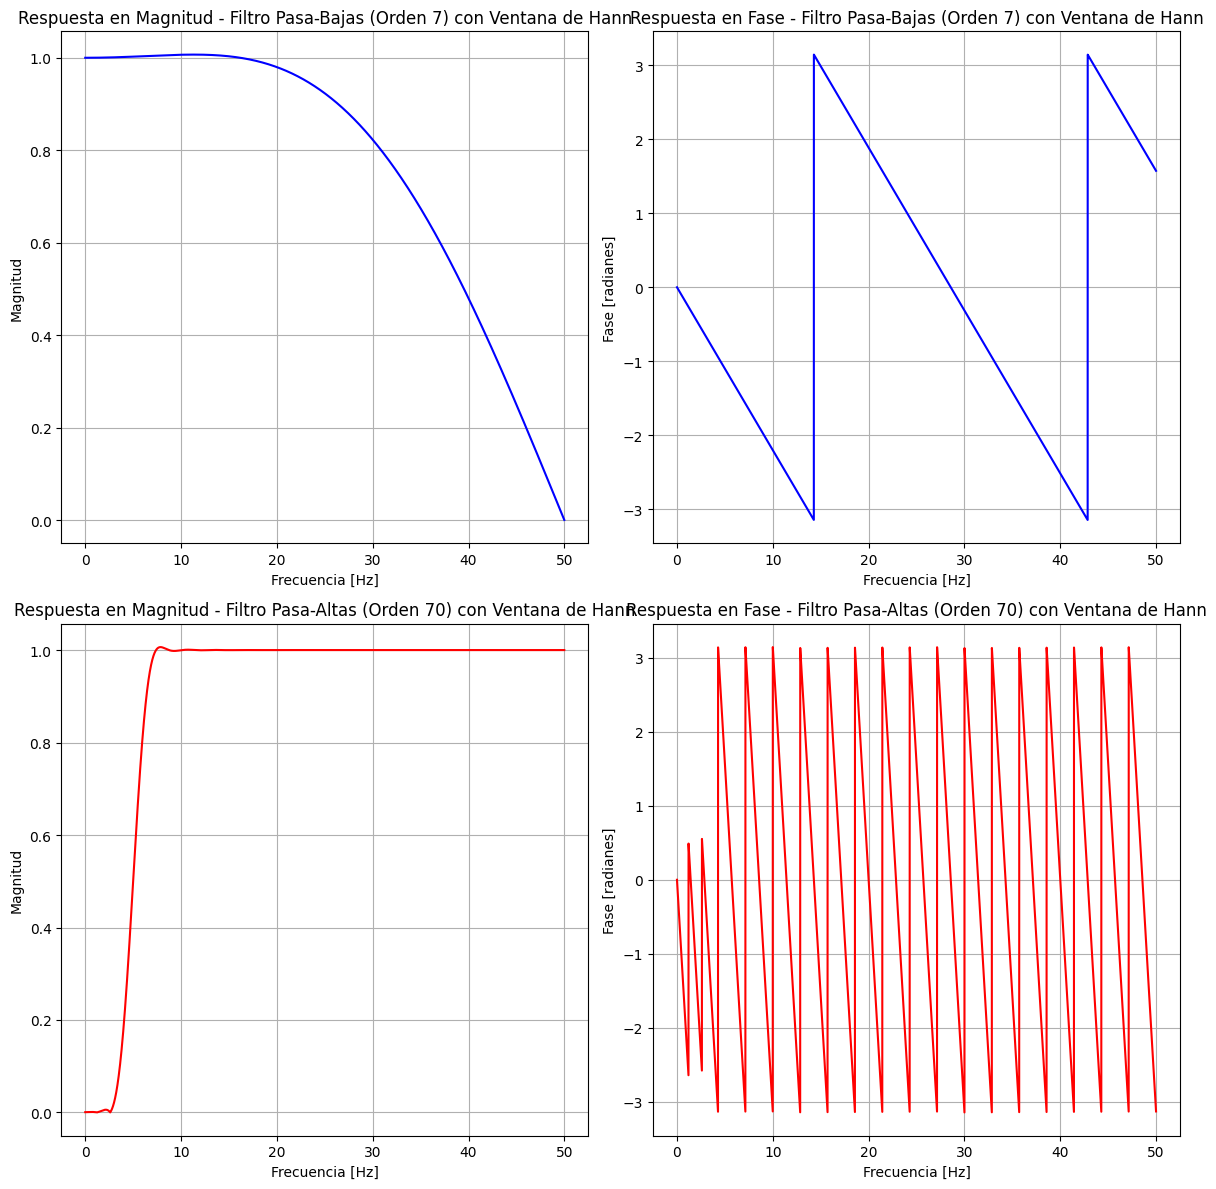

In [11]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# Parámetros
fs = 100  # Frecuencia de muestreo en Hz
f_c2 = 5  # Frecuencia de corte para el filtro pasa-altas
f_c1 = 40

nyquist = fs / 2
cutoff1 = f_c1 / nyquist  # Frecuencia de corte normalizada para el filtro pasa-bajas
cutoff2 = f_c2 / nyquist  # Frecuencia de corte normalizada para el filtro pasa-altas

# Orden de los filtros
order_low = 7    # Orden para filtro pasa-bajas
order_high = 70  # Orden para filtro pasa-altas

# Diseño de los filtros usando ventana Hann
low_pass_filter = signal.firwin(order_low + 1, cutoff1, window='hann', pass_zero=True)
high_pass_filter = signal.firwin(order_high + 1, cutoff2, window='hann', pass_zero=False)

# Respuesta en frecuencia de los filtros
w_low, h_low = signal.freqz(low_pass_filter, worN=8000, fs=fs)
w_high, h_high = signal.freqz(high_pass_filter, worN=8000, fs=fs)

# Graficar la respuesta en frecuencia
plt.figure(figsize=(12, 12))

# Respuesta en magnitud y fase para filtro pasa-bajas
plt.subplot(2, 2, 1)
plt.plot(w_low, np.abs(h_low), 'b')
plt.title('Respuesta en Magnitud - Filtro Pasa-Bajas (Orden 7) con Ventana de Hann')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(w_low, np.angle(h_low), 'b')
plt.title('Respuesta en Fase - Filtro Pasa-Bajas (Orden 7) con Ventana de Hann')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [radianes]')
plt.grid(True)

# Respuesta en magnitud y fase para filtro pasa-altas
plt.subplot(2, 2, 3)
plt.plot(w_high, np.abs(h_high), 'r')
plt.title('Respuesta en Magnitud - Filtro Pasa-Altas (Orden 70) con Ventana de Hann')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(w_high, np.angle(h_high), 'r')
plt.title('Respuesta en Fase - Filtro Pasa-Altas (Orden 70) con Ventana de Hann')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [radianes]')
plt.grid(True)

plt.tight_layout()
plt.show()
